# Final report calculations — 2026-08-10

Working notebook for the Pi$^2$ final report (`Pi2Su26/final_report/`): numbers
for the tables and final figure polish. First up: the **measured Bessel-window
range** for each optics configuration candidate of the report's `tab:configs`,
in the report format `L (z ∈ [lo, hi])` (meters, z from axicon 3).

| Candidate | Dataset | Envelope source (existing reduction caches) |
|---|---|---|
| #1 baseline | jul22–23 (+ jul13 manual) | `onaxis_reduction_2026_07_23.json` (0.15 mm-aperture on-axis rate) + `axial_reduction_2026_07_23.json` manual `peak_rate` |
| #2 input beam 2× | jul29–30 | `ax3_reduction_2026_07_29.json` per-slice peak-pixel rate |
| #3 smaller hollow beam | aug5–6 direct | `ax3_core_frames_2026_08_06.csv` best unsaturated core-frame rate |
| #4 = #3 + 2× telescope in zone | aug5–6 telescope | `telescope_core_frames_2026_08_06.csv` — **image-side** $z'$ after f_200mm; image↔object offset NOT recorded, so no object-side mapping yet |

Method: per y, envelope = max unsaturated rate across runs/frames; window =
FWHM about the global peak (linear-interpolated half crossings, walking out
from the peak). Edges beyond the scanned span are reported as unbounded.

Caveats (candidates #1–#2 especially): same-y runs differ up to ~2× in
absolute rate (independent exposure cal + laser drift), and #1's gantry
estimator (aperture mean) differs from the others (peak pixel) — the FWHM
uses only relative shape within one dataset, but the max-over-runs envelope
can inherit steps at run boundaries. Real sub-half dips inside the window
(jul29: ~1.70/1.85 m) are printed as warnings, not excluded.

In [1]:
import csv
import json
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

REPO = Path.cwd().parent
RED = Path("reductions")

# simulator import (not needed for the measured ranges, kept for later cells);
# webapp repo has both historical spellings
for _name in ("bessel_beam_webapp",):  # NB trailing comma: bare ("x") iterates characters
    if (REPO.parent / _name).exists():
        sys.path.insert(0, str(REPO.parent / _name))
        break

NOTEBOOK_STEM = "final_report_calcs_2026_08_10"
IMAGES_DIR = Path("images") / NOTEBOOK_STEM
IMAGES_DIR.mkdir(parents=True, exist_ok=True)


def save_fig(description):
    path = IMAGES_DIR / f"{description}.png"
    plt.savefig(path, dpi=200, bbox_inches="tight")
    print(f"saved {path}")

In [2]:
# --- measured Bessel-window ranges, all four candidates ----------------------
# 1. build per-candidate axial envelopes from the existing reduction caches
#    (per y: max unsaturated rate across runs/frames; no raw frames touched)
# 2. FWHM about the global peak: walk out from the peak to the first sample
#    below half, linear-interpolate the crossing; data ending first => edge
#    unbounded (None)
# 3. print each result in the report format  L ($z \in [lo, hi]$)


def envelope(pairs):
    d = {}
    for y, r in pairs:
        d[y] = max(d.get(y, 0.0), r)
    ys = np.array(sorted(d))
    return ys, np.array([d[y] for y in ys])


def fwhm(ys, I):
    i = int(np.argmax(I))
    half = 0.5 * I[i]
    lo = hi = None
    for j in range(i, -1, -1):
        if I[j] < half:
            lo = np.interp(half, [I[j], I[j + 1]], [ys[j], ys[j + 1]])
            break
    for j in range(i, len(I)):
        if I[j] < half:
            # NB np.interp needs INCREASING xp — [I[j-1], I[j]] here is
            # decreasing and silently returns garbage (bug found 08-10 when
            # #4's upper edge came out 0.95 instead of 0.79)
            hi = np.interp(half, [I[j], I[j - 1]], [ys[j], ys[j - 1]])
            if ys[j] - ys[j - 1] > 2.5:
                print(f"  NOTE upper crossing interpolated across a "
                      f"{(ys[j] - ys[j - 1]):.0f} cm data gap "
                      f"[{ys[j - 1] / 100:.2f}, {ys[j] / 100:.2f}] m")
            break
    dips = [float(ys[j]) for j in range(len(I))
            if (lo or ys[0]) < ys[j] < (hi or ys[-1]) and I[j] < half]
    return dict(y_peak=ys[i], peak=I[i], half=half, lo=lo, hi=hi, dips=dips)


def report(name, ys, I, unit="z"):
    w = fwhm(ys, I)
    lo = None if w["lo"] is None else w["lo"] / 100
    hi = None if w["hi"] is None else w["hi"] / 100
    if lo is not None and hi is not None:
        txt = f"{hi - lo:.2f} (${unit} \\in [{lo:.2f}, {hi:.2f}]$)"
    else:
        span = (f"[{'?' if lo is None else f'{lo:.2f}'}, "
                f"{'?' if hi is None else f'{hi:.2f}'}]")
        txt = (f"UNBOUNDED {span} — scan span "
               f"[{ys[0] / 100:.2f}, {ys[-1] / 100:.2f}] m")
    print(f"{name}\n  peak {w['peak']:.3g} c/us at {w['y_peak'] / 100:.2f} m"
          f"   ->  {txt}")
    print(w)
    if w["dips"]:
        print(f"  WARNING sub-half dips inside window at y = "
              f"{[round(d / 100, 2) for d in w['dips']]} m")
    return (ys, I, w, name)


ENV = {}

# --- #1 baseline: jul22-23 gantry on-axis + jul13 manual ---------------------
onax = json.load(open(RED / "onaxis_reduction_2026_07_23.json"))
ys, I = envelope([(e["beam_y_cm"], e["onax_rate"]) for e in onax
                  if not e["sat_flag"]])
ENV["#1 gantry (on-axis 0.15 mm aperture)"] = report(
    "#1 baseline — jul22-23 gantry", ys, I)

man = json.load(open(RED / "axial_reduction_2026_07_23.json"))["manual"]
# manual runs renamed *_EXCLUDED on disk (REPO/data) are dropped — the
# reduction JSON predates the renames, so match by run-name prefix; when
# data/ is unavailable (container execution) fall back to the known list
_man_dir = REPO / "data"
EXCLUDED_MANUAL = ({p.name[:-len("_EXCLUDED")]
                    for p in _man_dir.glob("manual_scan-*_EXCLUDED")}
                   if _man_dir.exists()
                   else {"manual_scan-2026-07-13_17-15-59"})  # z=140 cm dip
if EXCLUDED_MANUAL:
    print(f"manual runs excluded: {sorted(EXCLUDED_MANUAL)}")
ys, I = envelope([(e["z_cm"], e["peak_rate"]) for e in man
                  if e.get("z_reference") == "axicon3"
                  and e["run"] not in EXCLUDED_MANUAL])
ENV["#1 manual jul13 (peak pixel)"] = report(
    "#1 baseline — jul13 manual", ys, I)

# --- #2 input 2x: jul29-30 per-slice peak rates ------------------------------
ax3 = json.load(open(RED / "ax3_reduction_2026_07_29.json"))
EXCLUDE_RUNS = {"auto_scan-2026-07-29_13-03-58"}
ys, I = envelope([(e["beam_y_cm"], e["peak"]["rate"]) for e in ax3
                  if e["run"] not in EXCLUDE_RUNS
                  and e["n_sat"] == 0 and not e["lower_bound"]])
ENV["#2 (peak pixel)"] = report("#2 input 2x — jul29-30", ys, I)

# --- #3 direct & #4 telescope: aug5-6 core-frame CSVs ------------------------
# NB the aug6 CSVs currently contain BOTH placement families (cache
# regeneration collision) — filter by frame-name prefix, not by file.
for cand, f, pref, unit in (
        ("#3 smaller hollow beam — aug5-6 direct",
         "ax3_core_frames_2026_08_06.csv",
         ("aug5_axicon3", "aug6_axicon3"), "z"),
        ("#4 = #3 + 2x telescope in zone (IMAGE-side z' after f_200mm)",
         "telescope_core_frames_2026_08_06.csv",
         ("aug6_telescope",), "z'")):
    rows = [r for r in csv.DictReader(open(RED / f))
            if r["excluded_run"] == "False" and int(r["n_sat_px"]) == 0
            and r["frame"].startswith(pref)]
    ys, I = envelope([(float(r["beam_y_cm"]), float(r["rate_c_per_us"]))
                      for r in rows])
    ENV[cand] = report(cand, ys, I, unit=unit)

  NOTE upper crossing interpolated across a 4 cm data gap [1.68, 1.71] m
#1 baseline — jul22-23 gantry
  peak 0.106 c/us at 1.44 m   ->  0.43 ($z \in [1.26, 1.69]$)
{'y_peak': np.float64(144.0), 'peak': np.float64(0.10596748954178165), 'half': np.float64(0.05298374477089082), 'lo': np.float64(125.97920096080017), 'hi': np.float64(169.15430366731914), 'dips': []}
manual runs excluded: ['manual_scan-2026-07-13_17-15-59']
  NOTE upper crossing interpolated across a 5 cm data gap [1.60, 1.65] m
#1 baseline — jul13 manual
  peak 0.767 c/us at 1.55 m   ->  0.22 ($z \in [1.39, 1.61]$)
{'y_peak': np.float64(155.0), 'peak': np.float64(0.7667943668012548), 'half': np.float64(0.3833971834006274), 'lo': np.float64(139.08564756164603), 'hi': np.float64(161.08668836390513), 'dips': []}
#2 input 2x — jul29-30
  peak 0.603 c/us at 1.99 m   ->  UNBOUNDED [1.89, ?] — scan span [0.60, 2.01] m
{'y_peak': np.float64(199.0), 'peak': np.float64(0.6034632948827907), 'half': np.float64(0.30173164744139536), 'l

saved images/final_report_calcs_2026_08_10/measured_window_envelopes.png


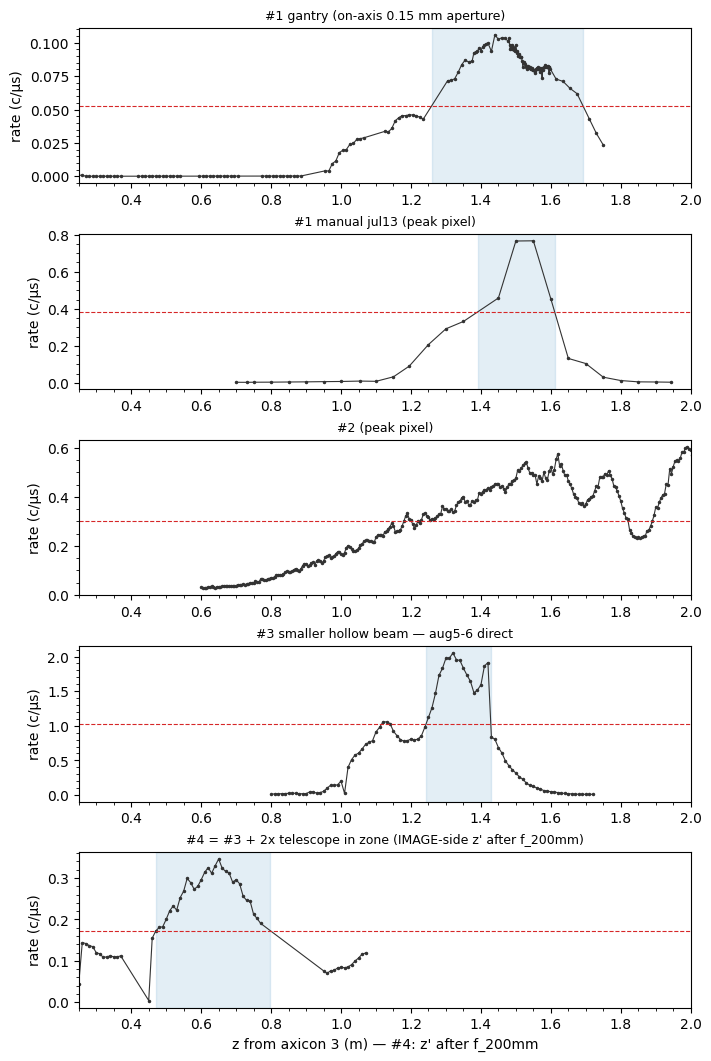

In [3]:
# --- envelope + window overview (sanity check of the crossings) --------------
fig, axes = plt.subplots(len(ENV), 1, figsize=(7, 2.1 * len(ENV)),
                         sharex=False, layout="constrained")
for ax, (label, (ys, I, w, _)) in zip(axes, ENV.items()):
    ax.plot(ys / 100, I, ".-", ms=3, lw=0.8, color="0.2")
    ax.axhline(w["half"], color="tab:red", lw=0.8, ls="--")
    if w["lo"] is not None and w["hi"] is not None:
        ax.axvspan(w["lo"] / 100, w["hi"] / 100, color="tab:blue", alpha=0.12)
    ax.set_title(label, fontsize=9)
    ax.set_ylabel("rate (c/µs)")
    ax.set_xlim(0.25, 2.0)
    ax.minorticks_on()
axes[-1].set_xlabel("z from axicon 3 (m) — #4: z' after f_200mm")
save_fig("measured_window_envelopes")
plt.show()

## Fits-based measured windows (absolutely scaled J$_0^2$ amplitudes)

Same windows, better estimator: instead of the raw peak-pixel rate, the axial
envelope is the fitted central-lobe amplitude $A/T$ (counts/µs) from a radial
J$_0^2$ fit to each cached core thumbnail — robust to hot pixels and pixel
sampling, with per-point 1$\sigma$ errors and an rms/A quality cut
(`rms_r <= 0.06`, same as the central-lobe notebooks). Inputs are the existing
thumbnail caches; candidate #1 has no thumbnail cache, so it keeps the
peak-pixel/aperture result above.

Because the jul29 dips at ~1.70/1.85 m are real (they reproduce in the aug3
re-scan), the from-peak FWHM still degenerates for #2 — so both definitions
are printed: **from-peak** (walk out from the peak, comparable to the QDHT
column's definition) and **outermost 50\% crossings** with the deepest
in-window ripple quoted alongside. For profiles without sub-half ripple the
two coincide.

In [4]:
# --- fits-based axial envelopes + both window definitions --------------------
# 1. per dataset: join thumbnail cache -> core-frame CSV (exposure, n_sat_px);
#    fills-the-square filter (any NaN in crop = clipped -> skip)
# 2. per thumb: sub-pixel centroid, azimuthal-mean radial profile, fit
#    A*J0^2(k u) + C over |u| <= fit_half; keep k in 0.2-4x ideal_eff
# 3. per y: envelope = max A/T among clean fits (rms/A <= 0.06)
# 4. windows: from-peak FWHM (comparable to the model column) AND outermost
#    50% crossings + deepest in-window ripple
from scipy.optimize import curve_fit
from scipy.special import j0
from simulator.qdht_axicon import axicon_kr

KR3 = axicon_kr(0.5)
RMS_OK = 0.06


def j0sq(u_um, A, k, C):
    return A * j0(k * u_um * 1e-6) ** 2 + C


def radial_profile(t, um_per_px):
    # sub-pixel centroid: 3x3-mean argmax, then intensity-weighted in +-7 px
    s = t.copy()
    s[1:-1, 1:-1] = (t[:-2, :-2] + t[:-2, 1:-1] + t[:-2, 2:] +
                     t[1:-1, :-2] + t[1:-1, 1:-1] + t[1:-1, 2:] +
                     t[2:, :-2] + t[2:, 1:-1] + t[2:, 2:]) / 9.0
    iy, ix = np.unravel_index(np.argmax(s), s.shape)
    y0, y1 = max(iy - 7, 0), min(iy + 8, t.shape[0])
    x0, x1 = max(ix - 7, 0), min(ix + 8, t.shape[1])
    w = t[y0:y1, x0:x1]
    yy, xx = np.mgrid[y0:y1, x0:x1]
    cy, cx = (w * yy).sum() / w.sum(), (w * xx).sum() / w.sum()
    yy, xx = np.mgrid[:t.shape[0], :t.shape[1]]
    r_px = np.hypot(yy - cy, xx - cx)
    nb_ = np.round(r_px * 2).astype(int)  # half-pixel bins
    prof = np.bincount(nb_.ravel(), t.ravel()) / np.bincount(nb_.ravel())
    u_um = np.arange(len(prof)) * 0.5 * um_per_px
    return u_um, prof


def fit_thumb(t, um_per_px, k_ideal_eff, fit_half_um):
    u, I = radial_profile(t.astype(np.float32), um_per_px)
    ok = np.isfinite(I) & (u <= fit_half_um)
    p0 = [np.nanmax(I[ok]), k_ideal_eff, 0.0]
    popt, pcov = curve_fit(j0sq, u[ok], I[ok], p0=p0,
                           bounds=([0, 0.2 * k_ideal_eff, -np.inf],
                                   [np.inf, 4.0 * k_ideal_eff, np.inf]))
    resid = I[ok] - j0sq(u[ok], *popt)
    return popt, np.sqrt(np.diag(pcov)), np.sqrt(np.mean(resid**2)) / popt[0]


def window_outer(ys, I):
    i = int(np.argmax(I))
    half = 0.5 * I[i]
    above = I >= half
    lo = hi = None
    j = int(np.argmax(above))                  # first above-half sample
    if j > 0:
        lo = np.interp(half, [I[j - 1], I[j]], [ys[j - 1], ys[j]])
    j = len(I) - 1 - int(np.argmax(above[::-1]))   # last above-half sample
    if j < len(I) - 1:
        hi = np.interp(half, [I[j + 1], I[j]], [ys[j + 1], ys[j]])
    inw = (ys >= (lo or ys[0])) & (ys <= (hi or ys[-1]))
    ripple = I[inw].min() / I[i] if inw.any() else np.nan
    return dict(half=half, lo=lo, hi=hi, ripple=ripple, y_peak=ys[i], peak=I[i])


def exposures(csv_path):
    d = {}
    for r in csv.DictReader(open(csv_path)):
        if r["excluded_run"] == "False" and int(r["n_sat_px"]) == 0:
            d[(r["run"], r["frame"])] = float(r["exposure_us"])
    return d


# One dict per dataset:
#   label        - candidate name (report label; keys of FIT_ENV)
#   thumbs_npz   - cached core thumbnails (reductions/)
#   frames_csv   - core-frame CSV with per-frame exposure_us / n_sat_px
#   frame_prefix - keep only frames whose name starts with these placement
#                  prefixes; None = keep all (cache holds a single dataset).
#                  Needed for the aug6 caches, whose CSVs contain BOTH the
#                  direct and telescope placement families.
#   um_per_px    - thumbnail pixel pitch in um (fallback; the npz value wins)
#   fit_half_um  - radial J0^2 fit window, |u| <= this
#   mag          - transverse magnification M (fit k bounds scale as
#                  k_ideal/M; 2.0 for the in-zone telescope, else 1.0)
#   excluded_runs- run names dropped before fitting
FITSETS = (
    dict(label="#1 baseline — jul22-23 gantry",
         thumbs_npz="ax3_core_thumbs_2026_07_23.npz",
         frames_csv="ax3_core_frames_2026_07_23.csv",
         frame_prefix=None, um_per_px=6.9, fit_half_um=450.0, mag=1.0,
         excluded_runs=set()),
    dict(label="#2 input 2x — jul29-30",
         thumbs_npz="ax3_core_thumbs.npz",
         frames_csv="ax3_core_frames.csv",
         frame_prefix=None, um_per_px=6.9, fit_half_um=450.0, mag=1.0,
         excluded_runs={"auto_scan-2026-07-29_13-03-58"}),
    dict(label="#3 smaller hollow beam — aug5-6 direct",
         thumbs_npz="ax3_core_thumbs_2026_08_06.npz",
         frames_csv="ax3_core_frames_2026_08_06.csv",
         frame_prefix=("aug5_axicon3", "aug6_axicon3"),
         um_per_px=6.9, fit_half_um=450.0, mag=1.0, excluded_runs=set()),
    dict(label="#4 = #3 + 2x telescope (IMAGE-side z')",
         thumbs_npz="telescope_core_thumbs_2026_08_06.npz",
         frames_csv="telescope_core_frames_2026_08_06.csv",
         frame_prefix=("aug6_telescope",),
         um_per_px=13.8, fit_half_um=900.0, mag=2.0, excluded_runs=set()),
)

FIT_ENV = {}
for ds in FITSETS:
    name, pref = ds["label"], ds["frame_prefix"]
    fit_half, excl = ds["fit_half_um"], ds["excluded_runs"]
    z = np.load(RED / ds["thumbs_npz"], allow_pickle=True)
    um_px = (float(z["um_per_px"]) if "um_per_px" in z.files
             else ds["um_per_px"])
    T_exp = exposures(RED / ds["frames_csv"])
    k_eff = KR3 / ds["mag"]
    best = {}
    n_nan = n_noexp = n_fail = 0
    for t, y, run, fr in zip(z["thumbs"], z["ys_cm"], z["runs"], z["frames"]):
        if pref and not str(fr).startswith(pref):
            continue
        if str(run) in excl:
            continue
        if np.isnan(np.asarray(t, dtype=np.float32)).any():
            n_nan += 1
            continue
        T = T_exp.get((str(run), str(fr)))
        if T is None:
            n_noexp += 1  # saturated/excluded per CSV, or cache/CSV drift
            continue
        try:
            (A, k, C), perr, rms = fit_thumb(np.asarray(t), um_px, k_eff, fit_half)
        except RuntimeError:
            n_fail += 1
            continue
        if rms > RMS_OK:
            continue
        rate, err = A / T, perr[0] / T
        yy = float(y)
        if yy not in best or rate > best[yy][0]:
            best[yy] = (rate, err)
    ys = np.array(sorted(best))
    I = np.array([best[y][0] for y in ys])
    E = np.array([best[y][1] for y in ys])
    print(f"{name}: {len(ys)} y points "
          f"(skipped: {n_nan} clipped, {n_noexp} no-CSV/sat, {n_fail} no-fit)")
    report(f"  from-peak: {name}", ys, I)
    w = window_outer(ys, I)
    lo = "?" if w["lo"] is None else f"{w['lo'] / 100:.2f}"
    hi = "?" if w["hi"] is None else f"{w['hi'] / 100:.2f}"
    if w["lo"] is not None and w["hi"] is not None:
        span = f"{(w['hi'] - w['lo']) / 100:.2f} ($z \\in [{lo}, {hi}]$)"
    else:
        span = f"UNBOUNDED [{lo}, {hi}] — scan span [{ys[0]/100:.2f}, {ys[-1]/100:.2f}] m"
    print(f"  outermost 50%: {span}   deepest in-window ripple "
          f"{100 * w['ripple']:.0f}% of peak\n")
    FIT_ENV[name] = (ys, I, E, w)

/tmp/ipykernel_4012/2694268656.py:36: RuntimeWarning: invalid value encountered in divide
  prof = np.bincount(nb_.ravel(), t.ravel()) / np.bincount(nb_.ravel())


#1 baseline — jul22-23 gantry: 157 y points (skipped: 402 clipped, 0 no-CSV/sat, 1 no-fit)
  NOTE upper crossing interpolated across a 4 cm data gap [1.68, 1.71] m
  from-peak: #1 baseline — jul22-23 gantry
  peak 0.723 c/us at 1.48 m   ->  0.38 ($z \in [1.29, 1.68]$)
{'y_peak': np.float64(148.0), 'peak': np.float64(0.7226031348444812), 'half': np.float64(0.3613015674222406), 'lo': np.float64(129.43983852717054), 'hi': np.float64(167.7353287062657), 'dips': []}
  outermost 50%: 0.38 ($z \in [1.29, 1.68]$)   deepest in-window ripple 52% of peak



#2 input 2x — jul29-30: 272 y points (skipped: 320 clipped, 0 no-CSV/sat, 0 no-fit)
  from-peak: #2 input 2x — jul29-30
  peak 0.59 c/us at 1.99 m   ->  UNBOUNDED [1.89, ?] — scan span [0.60, 2.01] m
{'y_peak': np.float64(198.5), 'peak': np.float64(0.5903458875935176), 'half': np.float64(0.2951729437967588), 'lo': np.float64(188.93495277728667), 'hi': None, 'dips': []}
  outermost 50%: UNBOUNDED [1.18, ?] — scan span [0.60, 2.01] m   deepest in-window ripple 37% of peak



#3 smaller hollow beam — aug5-6 direct: 84 y points (skipped: 51 clipped, 3 no-CSV/sat, 0 no-fit)
  from-peak: #3 smaller hollow beam — aug5-6 direct
  peak 2 c/us at 1.32 m   ->  0.18 ($z \in [1.24, 1.43]$)
{'y_peak': np.float64(132.0), 'peak': np.float64(2.0029777455651914), 'half': np.float64(1.0014888727825957), 'lo': np.float64(124.34452974819868), 'hi': np.float64(142.82704239035488), 'dips': []}
  outermost 50%: 0.31 ($z \in [1.12, 1.43]$)   deepest in-window ripple 37% of peak



#4 = #3 + 2x telescope (IMAGE-side z'): 60 y points (skipped: 115 clipped, 0 no-CSV/sat, 0 no-fit)
  NOTE upper crossing interpolated across a 18 cm data gap [0.77, 0.95] m
  from-peak: #4 = #3 + 2x telescope (IMAGE-side z')
  peak 0.323 c/us at 0.65 m   ->  0.32 ($z \in [0.47, 0.79]$)
{'y_peak': np.float64(65.0), 'peak': np.float64(0.322767691046132), 'half': np.float64(0.161383845523066), 'lo': np.float64(46.8965803900741), 'hi': np.float64(78.5216316032488), 'dips': []}
  outermost 50%: 0.32 ($z \in [0.47, 0.79]$)   deepest in-window ripple 50% of peak



saved images/final_report_calcs_2026_08_10/measured_window_envelopes_fits.png


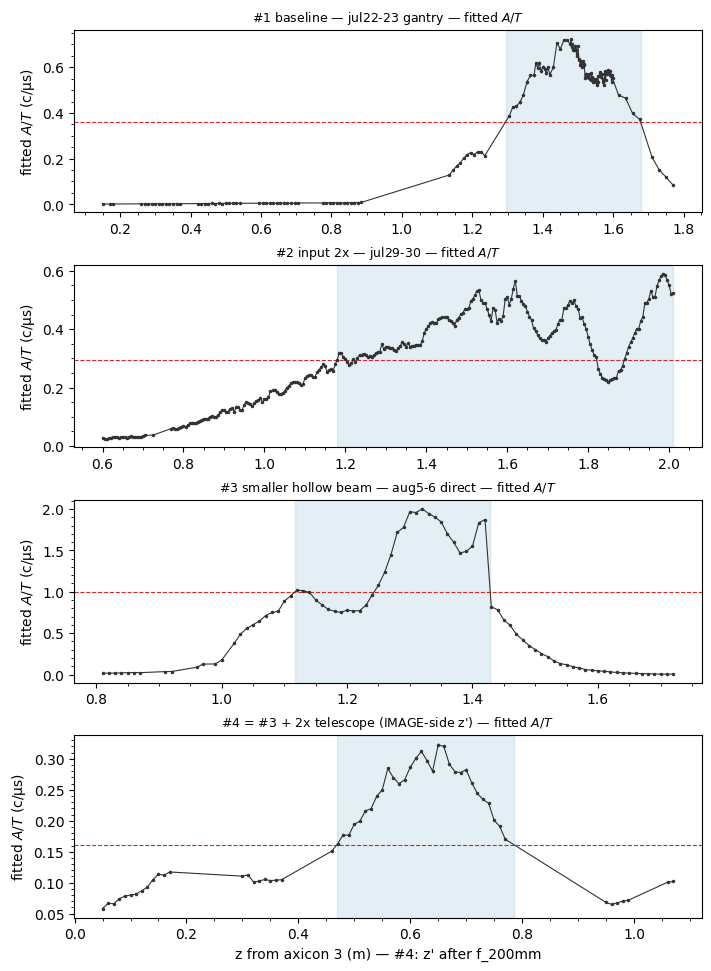

In [5]:
# --- fits-based envelopes: both window definitions overlaid ------------------
fig, axes = plt.subplots(len(FIT_ENV), 1, figsize=(7, 2.4 * len(FIT_ENV)),
                         layout="constrained")
for ax, (label, (ys, I, E, w)) in zip(np.atleast_1d(axes), FIT_ENV.items()):
    ax.errorbar(ys / 100, I, yerr=E, fmt=".-", ms=3, lw=0.8, color="0.2",
                elinewidth=0.6)
    ax.axhline(w["half"], color="tab:red", lw=0.8, ls="--")
    if w["lo"] is not None or w["hi"] is not None:
        ax.axvspan((w["lo"] or ys[0]) / 100, (w["hi"] or ys[-1]) / 100,
                   color="tab:blue", alpha=0.12)
    ax.set_title(label + " — fitted $A/T$", fontsize=9)
    ax.set_ylabel("fitted $A/T$ (c/µs)")
    # ax.set_yscale("log")
    ax.minorticks_on()
np.atleast_1d(axes)[-1].set_xlabel("z from axicon 3 (m) — #4: z' after f_200mm")
save_fig("measured_window_envelopes_fits")
plt.show()

cut at dip trough y = 1.85 m (envelope 0.220 c/us there); 240/272 points kept

#2 MAIN PLATEAU (final peak excluded)
  peak 0.566 c/us at 1.62 m   ->  0.61 ($z \in [1.21, 1.82]$)
{'y_peak': np.float64(162.0), 'peak': np.float64(0.5661182534365976), 'half': np.float64(0.2830591267182988), 'lo': np.float64(121.4543871045252), 'hi': np.float64(182.26243484760246), 'dips': []}
  outermost 50%: 0.65 ($z \in [1.18, 1.82]$)   deepest in-window ripple 49% of peak


saved images/final_report_calcs_2026_08_10/cand2_window_no_final_peak.png


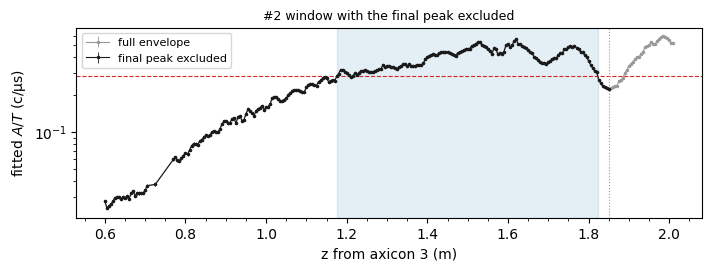

In [6]:
# --- #2 variant: exclude the final peak, re-derive the window ----------------
# Rationale to weigh: the final rise (peak 0.59 c/us at 1.99 m) sits right
# where QDHT puts the window peak (~1.88 m) and is cut off by the scan end at
# 2.01 m, so the full-envelope window is unbounded above. Cutting the
# envelope at the dip trough before the final rise gives the bounded window
# of the MAIN PLATEAU instead. Quote it only as such — it deliberately
# understates the full window.
ys2, I2, E2, _ = FIT_ENV["#2 input 2x — jul29-30"]

m = (ys2 >= 175) & (ys2 <= 199)               # bracket the last dip trough
y_cut = ys2[m][np.argmin(I2[m])]
keep = ys2 <= y_cut
print(f"cut at dip trough y = {y_cut / 100:.2f} m "
      f"(envelope {I2[m].min():.3f} c/us there); "
      f"{keep.sum()}/{len(ys2)} points kept\n")

report("#2 MAIN PLATEAU (final peak excluded)", ys2[keep], I2[keep])
w = window_outer(ys2[keep], I2[keep])
lo = "?" if w["lo"] is None else f"{w['lo'] / 100:.2f}"
hi = "?" if w["hi"] is None else f"{w['hi'] / 100:.2f}"
length = "" if None in (w["lo"], w["hi"]) else f"{(w['hi'] - w['lo']) / 100:.2f} "
print(f"  outermost 50%: {length}($z \\in [{lo}, {hi}]$)   "
      f"deepest in-window ripple {100 * w['ripple']:.0f}% of peak")

fig, ax = plt.subplots(figsize=(7, 2.6), layout="constrained")
ax.errorbar(ys2 / 100, I2, yerr=E2, fmt=".-", ms=3, lw=0.8, color="0.6",
            elinewidth=0.6, label="full envelope")
ax.errorbar(ys2[keep] / 100, I2[keep], yerr=E2[keep], fmt=".-", ms=3, lw=0.8,
            color="0.1", elinewidth=0.6, label="final peak excluded")
ax.axhline(w["half"], color="tab:red", lw=0.8, ls="--")
if w["lo"] is not None and w["hi"] is not None:
    ax.axvspan(w["lo"] / 100, w["hi"] / 100, color="tab:blue", alpha=0.12)
ax.axvline(y_cut / 100, color="tab:orange", lw=0.8, ls=":")
ax.set_xlabel("z from axicon 3 (m)")
ax.set_ylabel("fitted $A/T$ (c/µs)")
ax.set_yscale("log")
ax.minorticks_on()
ax.legend(fontsize=8)
ax.set_title("#2 window with the final peak excluded", fontsize=9)
save_fig("cand2_window_no_final_peak")
plt.show()